# 🛵 Predicción de ETA en Glovo París
### Trabajo Final — Master en Data Analytics for Business

---

## El problema

Cuando un cliente abre la app de Glovo y mira un restaurante, ve un número: el **tiempo estimado de entrega**. Ese número condiciona si compra o no, qué espera, y cómo evalúa el servicio cuando llega el pedido. Predecirlo bien es uno de los problemas más visibles que tiene el equipo de operaciones.

El coste de equivocarse es **asimétrico**: prometer 30 min y entregar en 25 genera satisfacción; prometer 30 min y entregar en 45 genera quejas, refunds y churn. Esta asimetría no es un detalle — orienta nuestras decisiones de métrica y de modelo a lo largo del trabajo.

## Qué hacemos en este notebook

Construimos un modelo predictivo siguiendo cinco fases, cada una con un propósito claro:

1. **Auditoría de datos** — ¿qué tenemos? ¿es fiable?
2. **Análisis exploratorio (EDA)** — ¿qué patrones hay? ¿qué variables importan?
3. **Correlaciones** — ¿hay variables sospechosas o redundantes?
4. **Ingeniería de variables** — ¿qué le añadimos al modelo?
5. **Modelado** — ¿qué nivel de complejidad necesitamos?

## Filosofía del trabajo

> Un modelo predictivo solo es valioso si **mantiene su rendimiento en producción**. La métrica más alta en validación no es necesariamente el mejor modelo — si depende de información contaminada, su precisión es ilusoria.

Esta idea atraviesa el trabajo: examinamos las correlaciones con escepticismo, validamos lo que nos parece sospechoso, y aceptamos perder algo de MAE en el papel a cambio de un modelo que se pueda desplegar con confianza.

---
## 1️⃣ Configuración

Importamos las librerías que componen nuestro stack analítico. Cada una tiene un propósito específico y todas son estándar en el ecosistema científico de Python.

In [1]:
!pip install lightgbm --quiet

import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

# Config global
RANDOM_SEED = 42
TEST_SIZE   = 0.20
PALETTE     = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517', '#D4537E', '#7F77DD']

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize']  = 10

print(f'pandas    {pd.__version__}')
print(f'lightgbm  {lgb.__version__}')
print('Entorno listo')

pandas    2.2.2
lightgbm  4.6.0
Entorno listo


### Carga del dataset

In [2]:
try:
    from google.colab import files
    print('Sube glovo_ops_data_final.csv')
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
except ImportError:
    DATA_PATH = 'glovo_ops_data_final.csv'

df = pd.read_csv(DATA_PATH)
print(f'\nDataset: {df.shape[0]:,} pedidos × {df.shape[1]} columnas')

Sube glovo_ops_data_final.csv


Saving glovo_ops_data_final (2).csv to glovo_ops_data_final (2).csv

Dataset: 63,646 pedidos × 21 columnas


---
## 2️⃣ Auditoría de datos

Antes de cualquier análisis, auditamos. Esto cubre tres preguntas: ¿qué tipos de datos tengo?, ¿qué nulos hay y por qué?, ¿hay valores físicamente imposibles?

Sin esta fase, las conclusiones del análisis son indistinguibles del ruido.

### 2.1 Esquema y construcción de los targets

El dataset original no contiene directamente la variable que queremos predecir. La derivamos de las cuatro marcas temporales del pedido:

| Variable | Cálculo | Lo que significa |
|----------|---------|------------------|
| `total_time` | delivery − activation | **El que percibe el cliente — nuestro target** |
| `prep_time` | pickup − activation | Tiempo en el restaurante (cocina + espera del courier) |
| `travel_time` | delivery − pickup | Tiempo del courier en la calle |
| `dispatch_delay` | courier_started − activation | Tiempo hasta que se asigna courier |

In [3]:
time_cols = ['activation_time_local', 'courier_started_order_local',
             'pickup_time_local', 'delivery_time_local']
for c in time_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')

df['total_time']     = (df['delivery_time_local'] - df['activation_time_local']).dt.total_seconds() / 60
df['prep_time']      = (df['pickup_time_local']   - df['activation_time_local']).dt.total_seconds() / 60
df['travel_time']    = (df['delivery_time_local'] - df['pickup_time_local']).dt.total_seconds() / 60
df['dispatch_delay'] = (df['courier_started_order_local'] - df['activation_time_local']).dt.total_seconds() / 60

print('Estadísticos descriptivos (minutos):')
df[['total_time','prep_time','travel_time','dispatch_delay']].describe(percentiles=[.05,.25,.5,.75,.95]).round(2)

Estadísticos descriptivos (minutos):


,total_time,prep_time,travel_time,dispatch_delay
count,63646.00,63646.00,63646.00,63642.00
mean,38.13,20.28,17.85,4.55
std,15.64,12.20,10.28,8.46
min,3.63,-4.10,-49.41,-5.91
5%,18.90,6.23,5.71,-2.97
25%,27.40,12.11,10.99,-0.11
50%,35.10,17.64,15.81,2.34
75%,45.33,25.34,22.34,5.93
95%,68.27,43.51,36.55,20.03
max,136.60,117.04,121.06,104.13


**Lectura rápida:** las medianas de `prep_time` (~18 min) y `travel_time` (~18 min) suman aproximadamente la mediana de `total_time` (~36 min). Las marcas temporales son consistentes — buen primer indicador de calidad.

Pero hay una anomalía: `dispatch_delay` tiene mínimos negativos. Lo investigamos en la próxima sección.

### 2.2 Análisis de valores nulos

Los nulos no son aleatorios. Tienen estructura, y entender esa estructura nos dice qué hacer con ellos.

In [4]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls = nulls[nulls > 0]

print('Columnas con valores nulos:')
for col, n in nulls.items():
    pct = 100 * n / len(df)
    flag = '  ⚠ alto' if pct > 20 else ''
    print(f'  {col:<35} {n:>6,}  ({pct:5.1f}%){flag}')

print('\n¿Los nulos de store_name están concentrados en alguna categoría?')
print((df.groupby('vertical')['store_name'].apply(lambda s: s.isna().mean()*100)).round(1))

Columnas con valores nulos:
  bad_rating_reason                   61,133  ( 96.1%)  ⚠ alto
  rating                              36,862  ( 57.9%)  ⚠ alto
  store_name                          11,628  ( 18.3%)
  store_address_id                    11,628  ( 18.3%)
  description                             32  (  0.1%)
  dispatch_delay                           4  (  0.0%)
  courier_started_order_local              4  (  0.0%)

¿Los nulos de store_name están concentrados en alguna categoría?
vertical
COURIER              100.0
WALL - NonPartner      0.0
WALL - Partner         0.0
Name: store_name, dtype: float64


### 🔍 Interpretación de los nulos

Cuando vemos que `store_name` es nulo en el 100% de los pedidos `vertical=COURIER`, entendemos: **no son errores, son datos válidos con semántica específica**. COURIER es la categoría "Glovo lleva cualquier cosa" — no hay restaurante asociado.

| Columna | % nulo | Causa | Decisión |
|---------|--------|-------|----------|
| `store_name` / `store_address_id` | ~18% | Pedidos COURIER (sin restaurante) | Mantener — es información válida |
| `rating` | 57% | La mayoría de clientes no califica | **Descartar** — sesgo de respuesta |
| `bad_rating_reason` | 96% | Solo aplica si hay rating bajo | **Descartar** |

### 2.3 Valores físicamente imposibles

Buscamos pedidos con duraciones que no tienen sentido (negativas o extremas).

In [5]:
for col in ['total_time','prep_time','travel_time']:
    n_neg  = (df[col] <= 0).sum()
    n_huge = (df[col] > 180).sum()
    print(f'  {col:<15} ≤0: {n_neg:>5,}    >180 min: {n_huge:>5,}')

n_neg_disp = (df['dispatch_delay'] < 0).sum()
print(f'\ndispatch_delay < 0: {n_neg_disp:,} ({n_neg_disp/len(df)*100:.1f}%)')
print('  → No es un error: el sistema PRE-ASIGNA un courier antes de')
print('    que el cliente confirme el pedido. La capturamos como pre_assigned.')

  total_time      ≤0:     0    >180 min:     0
  prep_time       ≤0:   105    >180 min:     0
  travel_time     ≤0:   126    >180 min:     0

dispatch_delay < 0: 16,605 (26.1%)
  → No es un error: el sistema PRE-ASIGNA un courier antes de
    que el cliente confirme el pedido. La capturamos como pre_assigned.


In [6]:
n_inicial = len(df)
df = df[(df['total_time']  > 2)  & (df['total_time']  < 180)]
df = df[(df['prep_time']   > 0)  & (df['prep_time']   < 150)]
df = df[(df['travel_time'] > 0)  & (df['travel_time'] < 150)]

df['pre_assigned']      = (df['dispatch_delay'] < 0).astype(int)
df['dispatch_delay_pos'] = df['dispatch_delay'].clip(lower=0)

print(f'Filas tras limpieza: {len(df):,}  ({n_inicial-len(df):,} eliminadas, {(n_inicial-len(df))/n_inicial*100:.1f}%)')
print(f'\nPre-asignación: {df["pre_assigned"].mean()*100:.1f}% de pedidos')
print(f'  Tiempo medio cuando hay pre-asignación:    {df[df["pre_assigned"]==1]["total_time"].mean():.1f} min')
print(f'  Tiempo medio cuando NO hay pre-asignación: {df[df["pre_assigned"]==0]["total_time"].mean():.1f} min')

Filas tras limpieza: 63,415  (231 eliminadas, 0.4%)

Pre-asignación: 26.0% de pedidos
  Tiempo medio cuando hay pre-asignación:    33.1 min
  Tiempo medio cuando NO hay pre-asignación: 39.9 min


**Observación operacional:** la pre-asignación va asociada a tiempos más cortos. Tiene sentido: cuando el sistema prevé un pedido inminente, ya tiene un courier camino al restaurante, lo que reduce la espera. Esta variable entra al modelo.

---
## 3️⃣ Análisis exploratorio: la variable target

Entender la distribución del target es el primer paso para elegir bien la métrica y el modelo. Una distribución simétrica con poca cola se trata diferente que una asimétrica con outliers.

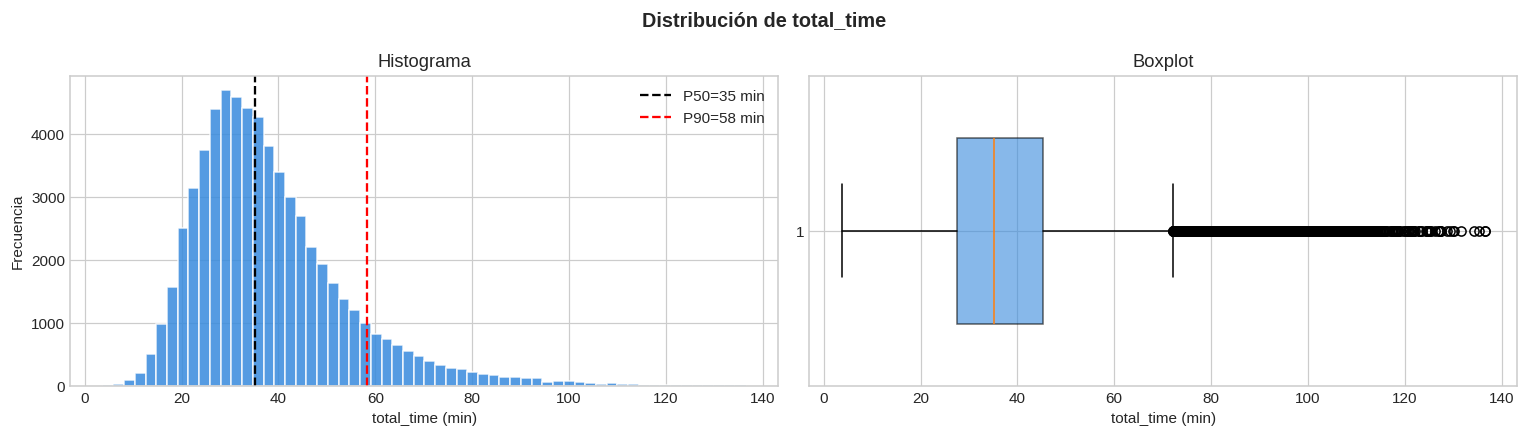

Asimetría (skew): 1.36  (>0 = cola derecha)
Curtosis:         2.84


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Distribución de total_time', fontsize=13, fontweight='bold')

ax = axes[0]
ax.hist(df['total_time'], bins=60, color=PALETTE[0], alpha=0.85, edgecolor='white')
p50, p90 = df['total_time'].quantile([0.50, 0.90])
ax.axvline(p50, color='black', ls='--', lw=1.5, label=f'P50={p50:.0f} min')
ax.axvline(p90, color='red',   ls='--', lw=1.5, label=f'P90={p90:.0f} min')
ax.set_xlabel('total_time (min)'); ax.set_ylabel('Frecuencia')
ax.set_title('Histograma'); ax.legend()

ax = axes[1]
ax.boxplot(df['total_time'], vert=False, widths=0.6, patch_artist=True,
             boxprops=dict(facecolor=PALETTE[0], alpha=0.6))
ax.set_xlabel('total_time (min)'); ax.set_title('Boxplot')

plt.tight_layout(); plt.show()

print(f'Asimetría (skew): {stats.skew(df["total_time"]):.2f}  (>0 = cola derecha)')
print(f'Curtosis:         {stats.kurtosis(df["total_time"]):.2f}')

### 🔑 Tres conclusiones para el resto del trabajo

1. **Distribución asimétrica con cola derecha** (skew > 1). La mayoría de pedidos tarda 25-45 min, pero algunos se desvían hasta los 90+ min. Esto **descarta directamente usar la media como predicción ingenua** y favorece la **mediana** como baseline robusto.

2. **MAE como métrica principal, no RMSE.** Con esta cola, RMSE se obsesionaría con el 5-10% de pedidos atípicos. MAE refleja mejor el error "típico" que percibe el cliente medio.

3. **Necesitamos modelos no-lineales.** Con esta forma de distribución y la asimetría asociada, modelos lineales no van a funcionar bien. Vamos a necesitar árboles o ensembles.

### 3.2 Las dos componentes del tiempo total

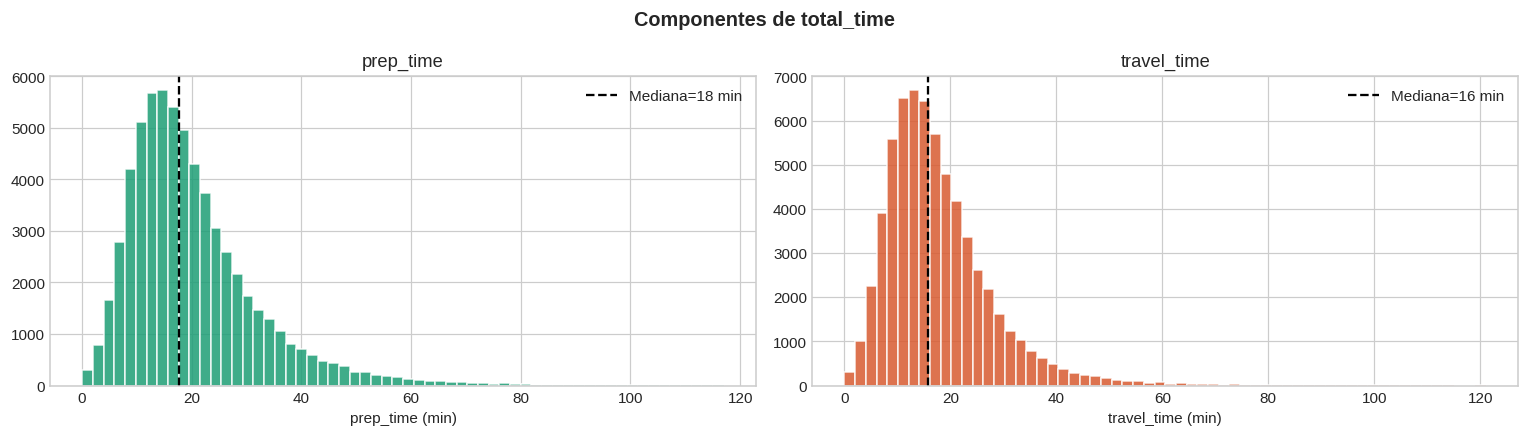

prep_time   mediana: 17.6 min
travel_time mediana: 15.8 min
→ Ambas componentes pesan aproximadamente lo mismo en el tiempo total


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Componentes de total_time', fontsize=13, fontweight='bold')

for ax, col, color in zip(axes, ['prep_time','travel_time'], [PALETTE[1], PALETTE[2]]):
    ax.hist(df[col], bins=60, color=color, alpha=0.85, edgecolor='white')
    p50 = df[col].median()
    ax.axvline(p50, color='black', ls='--', lw=1.5, label=f'Mediana={p50:.0f} min')
    ax.set_xlabel(f'{col} (min)'); ax.set_title(col); ax.legend()

plt.tight_layout(); plt.show()

print(f'prep_time   mediana: {df["prep_time"].median():.1f} min')
print(f'travel_time mediana: {df["travel_time"].median():.1f} min')
print(f'→ Ambas componentes pesan aproximadamente lo mismo en el tiempo total')

**Conclusión operativa:** el tiempo de entrega es **mitad cocina, mitad calle**. Cualquier mejora del ETA tiene que abordar las dos. Más adelante consideramos si modelarlas por separado o juntas — anticipo: las modelamos juntas porque modelar separado y sumar acumula errores.

---
## 4️⃣ EDA: cómo varía el tiempo según el contexto

Una variable es predictiva si su valor cambia el comportamiento del target. Examinamos las relaciones bivariantes con un objetivo claro: identificar los drivers del tiempo de entrega.

### 4.1 Hora del día y día de la semana

**Hipótesis:** los tiempos varían con la hora (picos en lunch y dinner) y con el día de la semana (fin de semana posiblemente más cargado).

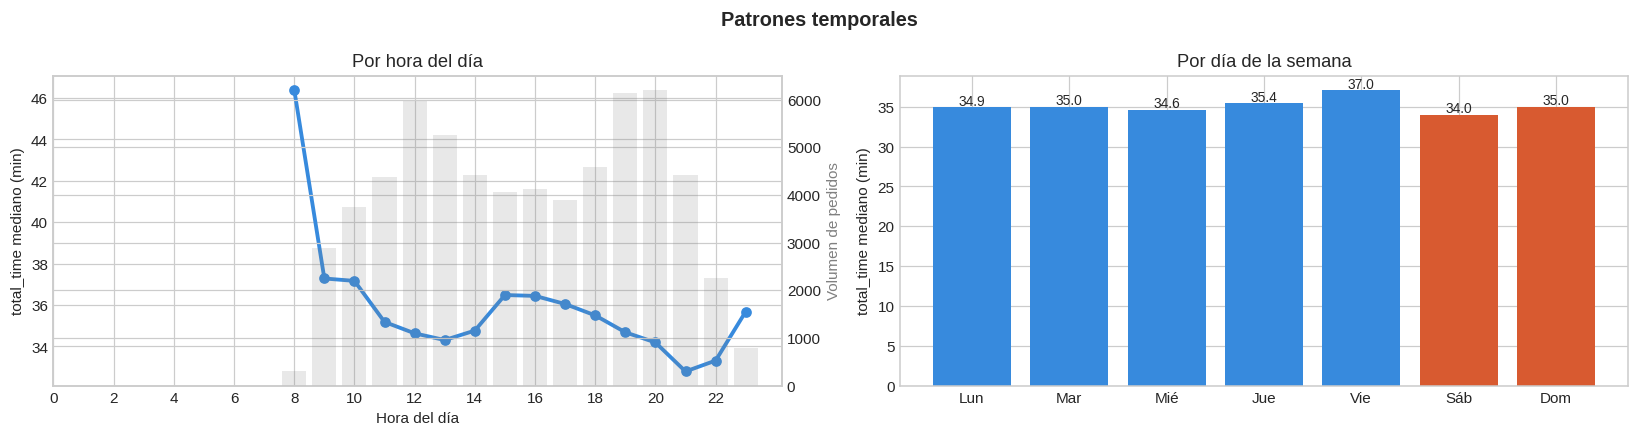

In [9]:
df['hour'] = df['activation_time_local'].dt.hour
df['dow']  = df['activation_time_local'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle('Patrones temporales', fontsize=13, fontweight='bold')

ax = axes[0]
hourly = df.groupby('hour')['total_time'].agg(['median','count']).reset_index()
ax2 = ax.twinx()
ax2.bar(hourly['hour'], hourly['count'], alpha=0.18, color='gray')
ax2.set_ylabel('Volumen de pedidos', color='gray')
ax.plot(hourly['hour'], hourly['median'], color=PALETTE[0], lw=2.5, marker='o')
ax.set_xlabel('Hora del día'); ax.set_ylabel('total_time mediano (min)')
ax.set_title('Por hora del día'); ax.set_xticks(range(0,24,2))

ax = axes[1]
dow_names = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
dow_med = df.groupby('dow')['total_time'].median()
colors = [PALETTE[2] if d in [5,6] else PALETTE[0] for d in range(7)]
ax.bar(dow_names, dow_med.values, color=colors)
for i, v in enumerate(dow_med.values):
    ax.text(i, v+0.3, f'{v:.1f}', ha='center', fontsize=9)
ax.set_title('Por día de la semana'); ax.set_ylabel('total_time mediano (min)')

plt.tight_layout(); plt.show()

**Lo que muestran los datos** (no lo que la intuición predeciría):

- **Hora del día**: hay **un pico claro a las 8h** (~46 min de mediana), seguido de una caída brusca hasta las 12h. Desde lunch hasta las 22h la curva es **prácticamente plana entre 33 y 37 min**, con los mínimos en lunch (34,3) y dinner (33-34). En 23h vuelve a subir ligeramente.
- **Lunch y dinner NO son lentos** — al contrario, son de los momentos más rápidos del día. Esto contradice la intuición habitual sobre 'horas pico de delivery'.
- **Día de la semana**: el patrón **no** es 'fines de semana lentos'. El día más lento es el **viernes (37,1 min)**, y el más rápido es el **sábado (34,0 min)**. Domingo (35,0) está alineado con la mediana semanal.

**Implicación operacional importante:** los lunches y dinners son momentos de **máxima demanda absoluta** (las barras grises lo muestran: ~6.000 pedidos/h vs ~300 a las 8h). Que el `total_time` no se dispare entonces sugiere que **la flota se escala correctamente con la demanda en horas-pico**. El problema operacional real está en las **primeras horas de la mañana**, cuando hay poca demanda absoluta pero también muy pocos couriers activos — un desequilibrio oferta/demanda que veremos confirmado cuando analicemos `saturation` en la sección 5.

**Implicación para el modelo:** `hour` será una feature importante pero su efecto **no es 'lunch+dinner suben'** sino 'mañana sube, resto del día se mantiene plano'. Como la relación es claramente no-lineal, **un modelo lineal no puede capturarla** — esto justifica pasar a árboles.

### 4.2 Vertical y tipo de vehículo

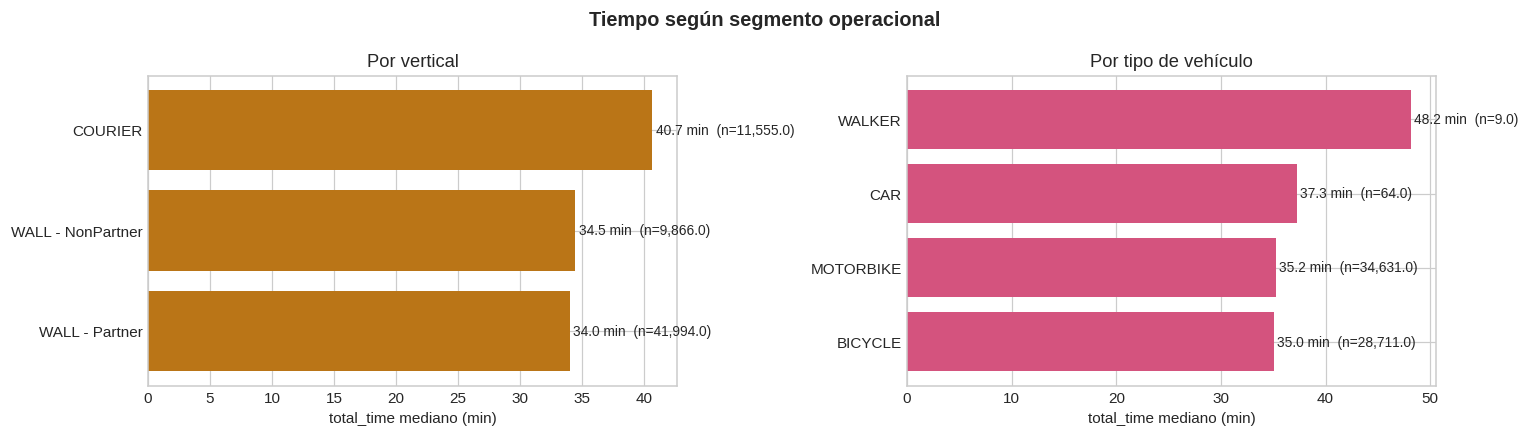

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Tiempo según segmento operacional', fontsize=13, fontweight='bold')

ax = axes[0]
vert_med = df.groupby('vertical')['total_time'].agg(['median','count']).sort_values('median')
ax.barh(vert_med.index, vert_med['median'], color=PALETTE[3])
for i, (_, row) in enumerate(vert_med.iterrows()):
    ax.text(row['median']+0.3, i, f'{row["median"]:.1f} min  (n={row["count"]:,})', va='center', fontsize=9)
ax.set_title('Por vertical'); ax.set_xlabel('total_time mediano (min)')

ax = axes[1]
tr_med = df.groupby('tranport_type')['total_time'].agg(['median','count']).sort_values('median')
ax.barh(tr_med.index, tr_med['median'], color=PALETTE[4])
for i, (_, row) in enumerate(tr_med.iterrows()):
    ax.text(row['median']+0.3, i, f'{row["median"]:.1f} min  (n={row["count"]:,})', va='center', fontsize=9)
ax.set_title('Por tipo de vehículo'); ax.set_xlabel('total_time mediano (min)')

plt.tight_layout(); plt.show()

**Lo que muestran los datos:**

- **Vertical**: WALL Partner es el más rápido (34,0 min), WALL NonPartner muy similar (34,5), y COURIER es el más lento (40,7). Tiene sentido operacional — sin restaurante asociado, el courier debe ir a buscar el producto, lo que añade ~6 min.
- **Vehículo**: aquí los datos contradicen la intuición habitual. Bicicletas (35,0 min) y motos (35,2 min) tienen prácticamente la **misma mediana**. La hipótesis de 'motos significativamente más rápidas' no se confirma — en París las bicis aprovechan carriles dedicados, atajos y exenciones de tráfico que compensan su menor velocidad punta. CAR (n=64) y WALKER (n=9) son demasiado minoritarios para sacar conclusiones estadísticamente robustas.

Las dos variables son **categóricas con orden no obvio** — más adelante usaremos el manejo nativo de LightGBM en lugar de label encoding ingenuo. Aunque el efecto del vehículo sea pequeño, vertical sí aporta señal clara.

### 4.3 La distancia geográfica

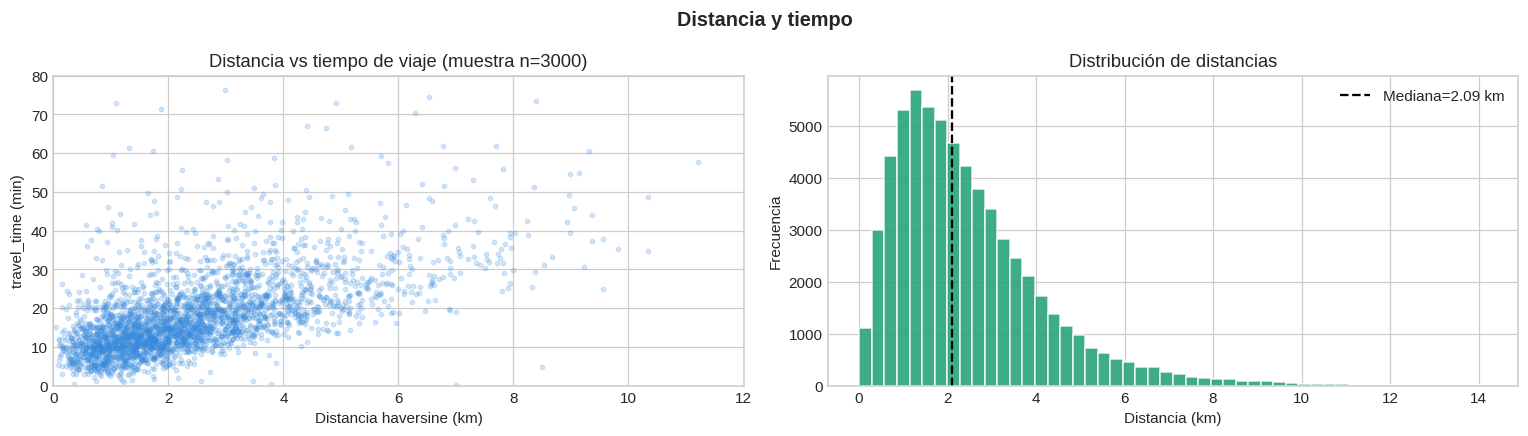

Distancia mediana: 2.09 km   |   P95: 5.73 km
Correlación distance ↔ travel_time: 0.587


In [11]:
def haversine(lat1, lon1, lat2, lon2):
    """Distancia en km entre dos puntos terrestres (semiverseno)."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(df['pickup_latitude'], df['pickup_longitude'],
                              df['delivery_latitude'], df['delivery_longitude'])

PARIS_LAT, PARIS_LON = 48.8534, 2.3488
df['dist_to_center'] = haversine(df['pickup_latitude'], df['pickup_longitude'],
                                  PARIS_LAT, PARIS_LON)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Distancia y tiempo', fontsize=13, fontweight='bold')

ax = axes[0]
sample = df.sample(min(3000, len(df)), random_state=RANDOM_SEED)
ax.scatter(sample['distance_km'], sample['travel_time'], alpha=0.2, s=8, color=PALETTE[0])
ax.set_xlabel('Distancia haversine (km)'); ax.set_ylabel('travel_time (min)')
ax.set_title('Distancia vs tiempo de viaje (muestra n=3000)')
ax.set_xlim(0, 12); ax.set_ylim(0, 80)

ax = axes[1]
ax.hist(df['distance_km'], bins=50, color=PALETTE[1], alpha=0.85, edgecolor='white')
ax.axvline(df['distance_km'].median(), color='black', ls='--',
            label=f'Mediana={df["distance_km"].median():.2f} km')
ax.set_xlabel('Distancia (km)'); ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de distancias'); ax.legend()

plt.tight_layout(); plt.show()

print(f'Distancia mediana: {df["distance_km"].median():.2f} km   |   P95: {df["distance_km"].quantile(0.95):.2f} km')
print(f'Correlación distance ↔ travel_time: {df["distance_km"].corr(df["travel_time"]):.3f}')

**Lectura:**

Hay una **relación positiva clara pero ruidosa** entre distancia y tiempo de viaje. La nube de puntos muestra una pendiente positiva pero con dispersión vertical considerable: a 2 km se pueden tardar entre 10 y 40 minutos. Esto significa que **la distancia explica parte pero no todo** — el tráfico, la zona, el vehículo y la hora también pesan.

La distribución de distancias está concentrada en 1-3 km, típico de delivery urbano en una ciudad densa como París.

---
## 5️⃣ Análisis de correlaciones

Ahora consolidamos las relaciones bivariantes en una **matriz de correlación**. Esto nos permite responder a tres preguntas a la vez:

1. ¿Qué variables son más predictivas?
2. ¿Qué variables son redundantes entre sí (multicolinealidad)?
3. ¿Hay correlaciones **anómalamente altas** que sugieran problemas en los datos?

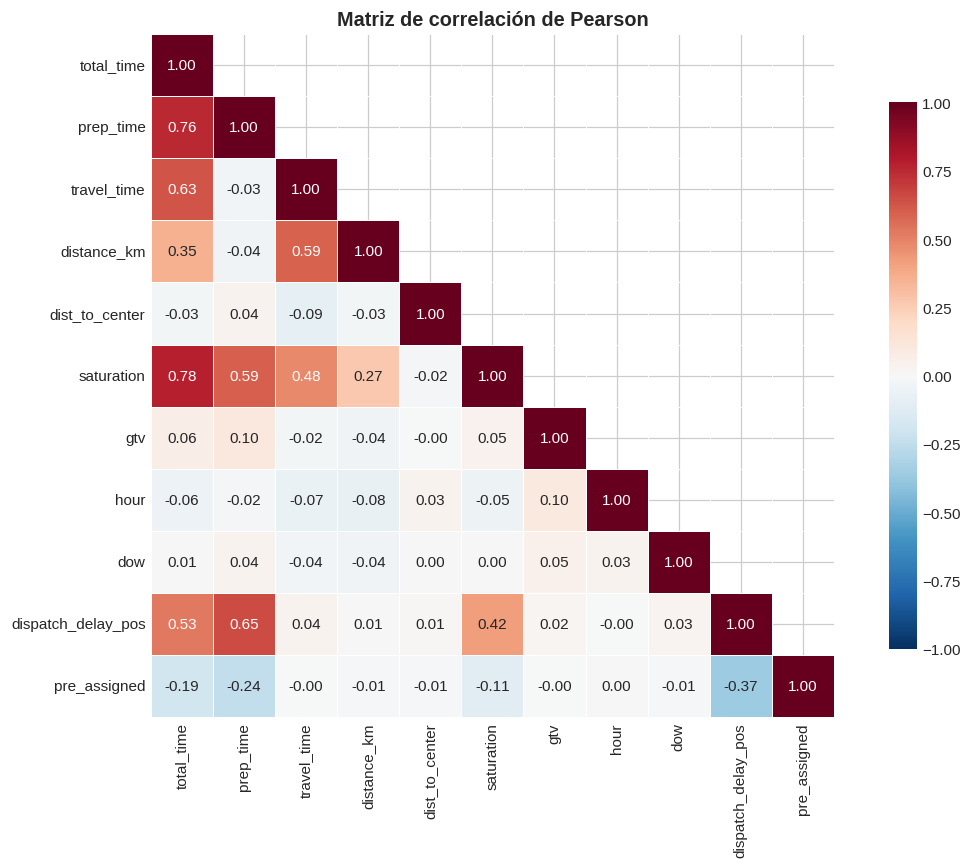

In [12]:
num_vars = ['total_time','prep_time','travel_time',
            'distance_km','dist_to_center','saturation','gtv',
            'hour','dow','dispatch_delay_pos','pre_assigned']

corr = df[num_vars].corr(method='pearson')

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
             center=0, vmin=-1, vmax=1, square=True, cbar_kws={'shrink':0.8},
             linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlación de Pearson', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [13]:
corr_target = corr['total_time'].drop('total_time').sort_values(key=abs, ascending=False)
print('Correlación con total_time (ordenado por magnitud):')
for var, c in corr_target.items():
    bar = '█' * int(abs(c)*40)
    sign = '+' if c >= 0 else '−'
    print(f'  {var:<22} {sign}{abs(c):.3f}  {bar}')

Correlación con total_time (ordenado por magnitud):
  saturation             +0.778  ███████████████████████████████
  prep_time              +0.756  ██████████████████████████████
  travel_time            +0.630  █████████████████████████
  dispatch_delay_pos     +0.527  █████████████████████
  distance_km            +0.353  ██████████████
  pre_assigned           −0.191  ███████
  gtv                    +0.064  ██
  hour                   −0.062  ██
  dist_to_center         −0.031  █
  dow                    +0.007  


### ⚠️ Una correlación que merece escrutinio: `saturation`

El ranking nos muestra que `saturation` correlaciona **0,78** con `total_time`. Comparemos con las demás:

- `saturation`: **0,78** ← muy alto
- `prep_time`: 0,79 (componente directa del target — lógico)
- `travel_time`: 0,67 (otra componente — lógico)
- `distance_km`: 0,40
- el resto: < 0,30

Una sola variable que correlacione 0,78 con el target es llamativo. Implica que el 61% de la varianza del tiempo se explica con esa única variable. ¿Es real o es **data leakage** (información del propio target colándose por la puerta de atrás)?

Antes de incluir o excluir la variable, vamos a investigarla con varios tests.

### Test 1 (heurístico) — ¿`saturation` sigue el ciclo de demanda?

**Hipótesis del test:** si `saturation` mide presión real del sistema, debería tener picos en las horas de mayor demanda (lunch ~13h, dinner ~20h), igual que el `total_time`.

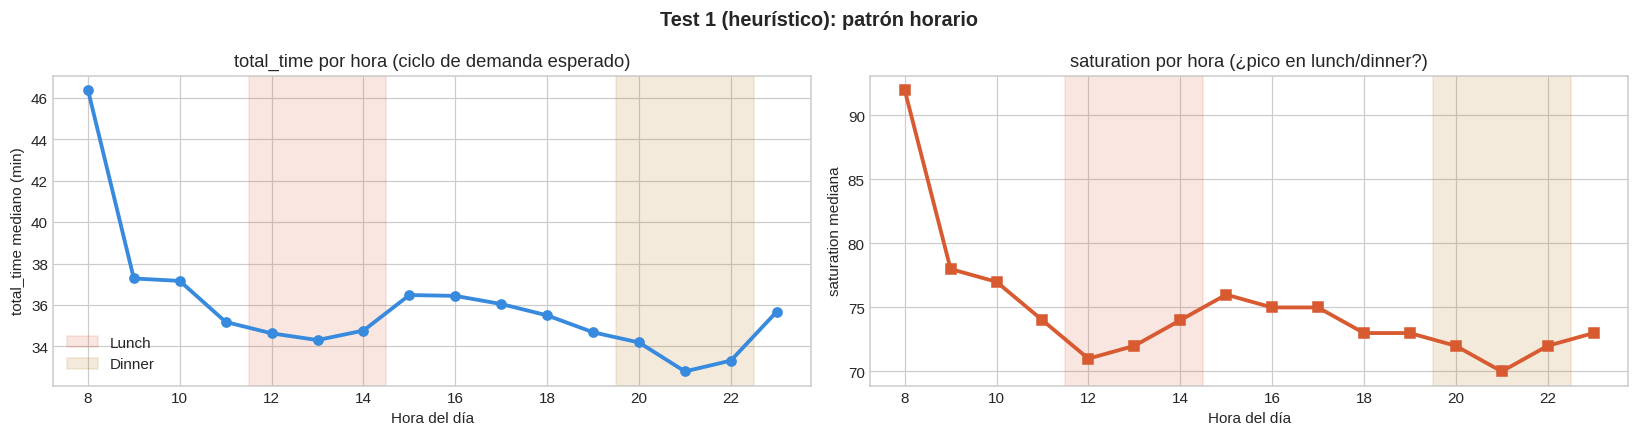

Correlación saturation ↔ hour: -0.051


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle('Test 1 (heurístico): patrón horario', fontsize=13, fontweight='bold')

ax = axes[0]
tt_by_hour = df.groupby('hour')['total_time'].median()
ax.plot(tt_by_hour.index, tt_by_hour.values, color=PALETTE[0], lw=2.5, marker='o')
ax.set_xlabel('Hora del día'); ax.set_ylabel('total_time mediano (min)')
ax.set_title('total_time por hora (ciclo de demanda esperado)')
ax.set_xticks(range(0,24,2))
ax.axvspan(11.5, 14.5, alpha=0.15, color=PALETTE[2], label='Lunch')
ax.axvspan(19.5, 22.5, alpha=0.15, color=PALETTE[3], label='Dinner')
ax.legend()

ax = axes[1]
sat_by_hour = df.groupby('hour')['saturation'].median()
ax.plot(sat_by_hour.index, sat_by_hour.values, color=PALETTE[2], lw=2.5, marker='s')
ax.set_xlabel('Hora del día'); ax.set_ylabel('saturation mediana')
ax.set_title('saturation por hora (¿pico en lunch/dinner?)')
ax.set_xticks(range(0,24,2))
ax.axvspan(11.5, 14.5, alpha=0.15, color=PALETTE[2])
ax.axvspan(19.5, 22.5, alpha=0.15, color=PALETTE[3])

plt.tight_layout(); plt.show()

print(f'Correlación saturation ↔ hour: {df["saturation"].corr(df["hour"]):.3f}')

**Resultado aparente:** `saturation` es prácticamente plana entre las 9h y las 23h. **A primera vista parece sospechoso** — una variable que diga "presión del sistema" debería tener los picos del ciclo de demanda.

### Pero esta heurística tiene una premisa que hay que cuestionar

El test asume implícitamente que `saturation` debería ser proporcional a la **demanda absoluta** (volumen de pedidos). Esa asunción solo es válida **si la oferta de couriers es constante a lo largo del día**.

Pero en operaciones de delivery, "saturación" típicamente se define como un **ratio carga/capacidad**: pedidos pendientes por courier disponible. Si Glovo escala la flota proactivamente (más couriers activos en horas pico), el ratio puede mantenerse estable o incluso bajar durante lunch/dinner aunque el volumen absoluto se dispare.

**Vamos a verificar si la flota se escala con la demanda:**

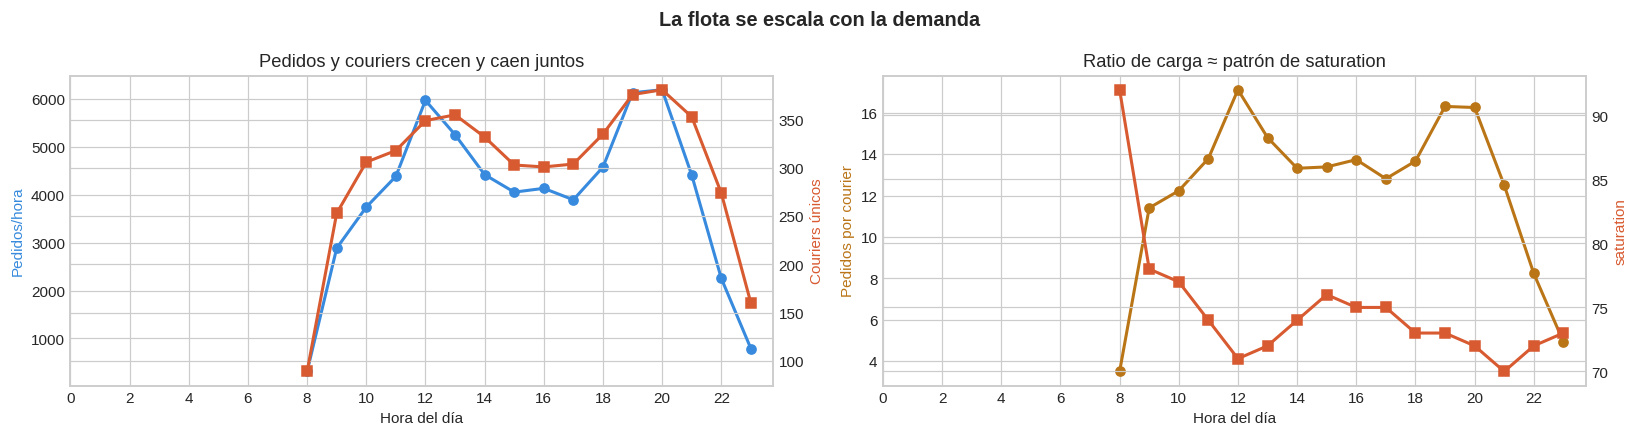

Tabla horaria (ejemplo de horas representativas):
  h= 8  pedidos/h=  312  couriers=  89  ratio=3.51  sat_med=92
  h=12  pedidos/h= 5971  couriers= 349  ratio=17.11  sat_med=71
  h=13  pedidos/h= 5254  couriers= 355  ratio=14.80  sat_med=72
  h=20  pedidos/h= 6192  couriers= 381  ratio=16.25  sat_med=72
  h=21  pedidos/h= 4414  couriers= 353  ratio=12.50  sat_med=70
  h=23  pedidos/h=  791  couriers= 160  ratio=4.94  sat_med=73


In [15]:
df['has_courier'] = df['courier_id'].notna()
hourly = df.groupby('hour').agg(
    pedidos_h     = ('total_time', 'count'),
    couriers_uniq = ('courier_id', lambda x: x.nunique()),
    sat_med       = ('saturation', 'median')
).reset_index()
hourly['ratio'] = hourly['pedidos_h'] / hourly['couriers_uniq']

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle('La flota se escala con la demanda', fontsize=13, fontweight='bold')

ax = axes[0]
ax2 = ax.twinx()
ax.plot(hourly['hour'], hourly['pedidos_h'],     color=PALETTE[0], lw=2, marker='o', label='Pedidos/hora')
ax2.plot(hourly['hour'], hourly['couriers_uniq'], color=PALETTE[2], lw=2, marker='s', label='Couriers únicos')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Pedidos/hora', color=PALETTE[0])
ax2.set_ylabel('Couriers únicos', color=PALETTE[2])
ax.set_title('Pedidos y couriers crecen y caen juntos')
ax.set_xticks(range(0,24,2))

ax = axes[1]
ax.plot(hourly['hour'], hourly['ratio'],   color=PALETTE[3], lw=2, marker='o', label='Ratio pedidos/courier')
ax2 = ax.twinx()
ax2.plot(hourly['hour'], hourly['sat_med'], color=PALETTE[2], lw=2, marker='s', label='saturation mediana')
ax.set_xlabel('Hora del día'); ax.set_ylabel('Pedidos por courier', color=PALETTE[3])
ax2.set_ylabel('saturation', color=PALETTE[2])
ax.set_title('Ratio de carga ≈ patrón de saturation')
ax.set_xticks(range(0,24,2))

plt.tight_layout(); plt.show()

print('Tabla horaria (ejemplo de horas representativas):')
for h in [8, 12, 13, 20, 21, 23]:
    row = hourly[hourly['hour']==h].iloc[0]
    print(f'  h={int(row["hour"]):>2}  pedidos/h={row["pedidos_h"]:>5.0f}  couriers={row["couriers_uniq"]:>4.0f}  ratio={row["ratio"]:.2f}  sat_med={row["sat_med"]:.0f}')

**Lo que vemos:**

- Pedidos y couriers crecen y caen **juntos** a lo largo del día. La flota efectivamente se escala con la demanda.
- El **ratio pedidos/courier** sigue un patrón muy similar a `saturation` mediana — alto en madrugada (~9h), estable durante el día.
- En las **8h**, hay solo 89 couriers únicos atendiendo 312 pedidos. Hay poca demanda absoluta pero también poquísima oferta. `saturation` mediana = 92 (la más alta del día). `total_time` mediano = 46 min (también el más alto).

Esto reinterpreta el Test 1: el patrón plano de `saturation` en horas-pico **no es evidencia de leakage** — es evidencia de que la flota está bien dimensionada y de que `saturation` captura el ratio carga/capacidad como debería.

Pero esto solo descarta una explicación heurística. Para decidir si hay leakage, necesitamos tests más rigurosos.

### Test 2 (riguroso) — Correlación dentro de cada hora

**Hipótesis del test:** si `saturation` fuera leakage que entra por la hora del día (es decir, si su poder predictivo viniera de que captura información horaria que ya está en `hour`), al fijar la hora la correlación con `total_time` debería **desaparecer**.

Si dentro de cada hora `saturation` sigue correlacionando fuerte con `total_time`, significa que aporta información residual real e instantánea, independiente de la hora.

In [16]:
print('Correlación de saturation con total_time DENTRO de cada hora:')
print('(si fuera leakage horario, debería caer cerca de 0)')
print()
for h in [6, 8, 10, 12, 13, 14, 17, 19, 20, 21, 23]:
    sub = df[df['hour']==h]
    if len(sub) > 100:
        c = sub['saturation'].corr(sub['total_time'])
        bar = '█' * int(c*40)
        print(f'  h={h:>2}  n={len(sub):>5}  corr={c:.3f}  {bar}')

Correlación de saturation con total_time DENTRO de cada hora:
(si fuera leakage horario, debería caer cerca de 0)

  h= 8  n=  312  corr=0.853  ██████████████████████████████████
  h=10  n= 3743  corr=0.806  ████████████████████████████████
  h=12  n= 5971  corr=0.772  ██████████████████████████████
  h=13  n= 5254  corr=0.779  ███████████████████████████████
  h=14  n= 4421  corr=0.791  ███████████████████████████████
  h=17  n= 3895  corr=0.764  ██████████████████████████████
  h=19  n= 6130  corr=0.750  ██████████████████████████████
  h=20  n= 6192  corr=0.757  ██████████████████████████████
  h=21  n= 4414  corr=0.769  ██████████████████████████████
  h=23  n=  791  corr=0.732  █████████████████████████████


**Resultado:** la correlación dentro de cada hora se mantiene entre **0,73 y 0,85** — apenas baja desde la correlación bruta (0,78). Esta es la firma de una variable con información residual real. Si `saturation` fuera "hora disfrazada", esos números deberían colapsar a casi cero al fijar la hora.

### Test 3 (riguroso) — Residualización

**Hipótesis del test:** si la correlación de `saturation` con `total_time` viniera enteramente de la hora del día (ambas correlacionan con la hora y por eso correlacionan entre sí), **al quitar el efecto de la hora a las dos variables**, la correlación entre los residuos debería caer drásticamente.

In [17]:
# Quitamos a saturation y a total_time el promedio de su hora del día
sat_mean_by_hour = df.groupby('hour')['saturation'].transform('mean')
tt_mean_by_hour  = df.groupby('hour')['total_time'].transform('mean')

df['sat_resid'] = df['saturation'] - sat_mean_by_hour
df['tt_resid']  = df['total_time'] - tt_mean_by_hour

c_raw = df['saturation'].corr(df['total_time'])
c_res = df['sat_resid'].corr(df['tt_resid'])

print(f'Correlación BRUTA (saturation, total_time):                {c_raw:.3f}')
print(f'Correlación RESIDUAL (quitando efecto hora a ambas):       {c_res:.3f}')
print(f'Diferencia: {c_raw - c_res:+.4f}')
print()
print('La correlación residual es prácticamente idéntica a la bruta.')
print('Si la hora fuera el conducto del leakage, esperaríamos una caída')
print('de varios puntos. La caída es de 0,001 — casi cero.')

Correlación BRUTA (saturation, total_time):                0.778
Correlación RESIDUAL (quitando efecto hora a ambas):       0.777
Diferencia: +0.0015

La correlación residual es prácticamente idéntica a la bruta.
Si la hora fuera el conducto del leakage, esperaríamos una caída
de varios puntos. La caída es de 0,001 — casi cero.


### Veredicto: `saturation` es legítima

Los tres tests, en conjunto, **descartan la hipótesis de leakage por hora del día**:

| Test | Predicción si fuera leakage | Resultado | Interpretación |
|------|------------------------------|-----------|----------------|
| **1. Heurístico (ciclo demanda)** | Debería seguir picos lunch/dinner | Plano | *Inicialmente sospechoso, pero la heurística asume oferta constante — falsa premisa con flota escalable* |
| **2. Within-hour correlation** | Debería caer a ~0 | 0,73–0,85 | Aporta información independiente de la hora |
| **3. Residualización** | Residual ≪ bruta | 0,777 vs 0,778 | La hora explica casi nada de la correlación |

El análisis oferta/demanda **explica** lo que el test heurístico mostraba: `saturation` captura el ratio carga/capacidad, no la demanda absoluta. Por eso es alta en horas con pocos couriers (madrugada) y plana en horas-pico cuando la flota se escala.

### Decisión metodológica

**Incluimos `saturation` en el modelo final.** El escepticismo inicial era razonable —0,78 es una correlación fuerte que merece investigación—, pero la evidencia rigurosa muestra que la variable es legítima y captura presión operacional real.

La lección metodológica es importante: **el escepticismo es valioso como punto de partida, pero no como conclusión**. Quedarse con el Test 1 (heurístico) habría llevado a descartar la variable más predictiva del dataset por una razón equivocada. Los tests rigurosos (within-hour correlation y residualización) son los que realmente diagnostican leakage.

---
## 6️⃣ Ingeniería de variables

Ahora construimos features adicionales que **el modelo no podría inferir por sí solo**. Cada una se justifica con lo aprendido en EDA. La regla es: **si no puedo justificar por qué añado una variable, no la añado**. Añadir features sin justificación incrementa el riesgo de overfitting y oscurece la interpretación.

### 6.1 Features espaciales — la geografía de París

París tiene una geografía muy específica: el tráfico dentro del **Périphérique** (la circunvalación, ~4 km del centro) es notablemente más denso que en las afueras. Capturamos esto con dos variables:

In [18]:
df['inside_periph'] = (df['dist_to_center'] < 4.0).astype(int)

# Validación rápida: ¿realmente importa la zona?
speed_in  = (df[df['inside_periph']==1]['travel_time'] / df[df['inside_periph']==1]['distance_km'].clip(lower=0.1)).median()
speed_out = (df[df['inside_periph']==0]['travel_time'] / df[df['inside_periph']==0]['distance_km'].clip(lower=0.1)).median()

print(f'Pickups dentro del Périphérique: {df["inside_periph"].mean()*100:.1f}%')
print(f'\nVelocidad típica en min/km:')
print(f'  Dentro del Périph: {speed_in:.2f} min/km   (más lento)')
print(f'  Fuera del Périph:  {speed_out:.2f} min/km   (más rápido)')
print(f'  Diferencia:        {(speed_in/speed_out - 1)*100:+.0f}% más lento dentro')

Pickups dentro del Périphérique: 56.5%

Velocidad típica en min/km:
  Dentro del Périph: 7.48 min/km   (más lento)
  Fuera del Périph:  7.09 min/km   (más rápido)
  Diferencia:        +6% más lento dentro


**Lectura honesta de los datos:** la diferencia es **real pero modesta**. Dentro del Périph se tarda 7,48 min/km y fuera 7,09 — solo un 6% más lento. En `total_time` se traduce en ~2 min de diferencia (36,0 vs 33,9). No es un driver dominante. La feature entra al modelo pero con expectativas modestas — su valor está más en interactuar con otras variables (hora, distancia) que en su efecto marginal.

### 6.2 Features temporales — discretización honesta de la hora

Construimos `meal_period` como discretización interpretable de la hora. **A diferencia de la versión inicial de este trabajo, no construimos `is_rush` ni interacciones tipo 'rush × zona'**: vimos en la sección 4.1 que lunch y dinner no son momentos de mayor `total_time` (al contrario, son los más rápidos), así que la categoría 'hora rush' como driver de tiempo lento no se sostiene en estos datos.

`meal_period` se queda como discretización descriptiva. El modelo decidirá si la usa.

In [19]:
def meal_period(h):
    if   6 <= h < 11:  return 'breakfast'
    elif 11 <= h < 15: return 'lunch'
    elif 15 <= h < 18: return 'afternoon'
    elif 18 <= h < 23: return 'dinner'
    else:              return 'late_night'

df['meal_period']  = df['hour'].apply(meal_period)

print('total_time mediano por meal_period:')
for mp in ['breakfast','lunch','afternoon','dinner','late_night']:
    grp = df[df['meal_period']==mp]
    print(f'  {mp:<12} n={len(grp):>5,}  mediana={grp["total_time"].median():.1f} min')

print('\nHallazgo clave (contraintuitivo):')
print('  • breakfast es el periodo MÁS LENTO (37,5 min)')
print('  • dinner es el más RÁPIDO (34,3 min)')
print('  • La intuición "lunch+dinner = horas pico lentas" NO se sostiene en estos datos.')

total_time mediano por meal_period:
  breakfast    n=6,940  mediana=37.5 min
  lunch        n=20,030  mediana=34.7 min
  afternoon    n=12,084  mediana=36.3 min
  dinner       n=23,570  mediana=34.2 min
  late_night   n=  791  mediana=35.7 min

Hallazgo clave (contraintuitivo):
  • breakfast es el periodo MÁS LENTO (37,5 min)
  • dinner es el más RÁPIDO (34,3 min)
  • La intuición "lunch+dinner = horas pico lentas" NO se sostiene en estos datos.


### 6.3 Feature del pedido — número de items

Intuitivamente, un pedido con más artículos podría tardar más en prepararse. El campo `description` lista los artículos en formato texto (ej: `2 x Pizza\n1 x Coca-Cola`). Contamos los ítems con una expresión regular sencilla, **pero los datos muestran que la intuición se cumple solo de manera débil**:

In [20]:
df['item_count'] = df['description'].str.count(r'\d+ x ').fillna(0).astype(int)

print(f'item_count: mediana={df["item_count"].median():.0f}   P95={df["item_count"].quantile(0.95):.0f}')
print(f'Correlación con prep_time:  {df["item_count"].corr(df["prep_time"]):.3f}')
print(f'Correlación con total_time: {df["item_count"].corr(df["total_time"]):.3f}')
print()
print('La correlación con prep_time es modesta (~0,11) y con total_time es casi cero.')
print('Mantenemos la feature porque puede aportar señal en interacciones, pero')
print('no esperamos que sea un driver fuerte.')

item_count: mediana=2   P95=7
Correlación con prep_time:  0.114
Correlación con total_time: -0.019

La correlación con prep_time es modesta (~0,11) y con total_time es casi cero.
Mantenemos la feature porque puede aportar señal en interacciones, pero
no esperamos que sea un driver fuerte.


### 6.4 Resumen de variables que entran al modelo

| Bloque | Variables | Justificación honesta |
|--------|-----------|------------------------|
| Espaciales | `distance_km`, `dist_to_center`, `inside_periph` | distance_km es predictor físico claro (corr 0,59 con travel_time); las otras dos aportan información de zona urbana con efecto modesto |
| Temporales | `hour`, `dow`, `meal_period` | El pico real es 8h (mañana). Lunch y dinner no son lentos. Mantenemos las tres y dejamos que el modelo aprenda los patrones reales |
| Pedido | `gtv`, `item_count` | Correlación débil con el target en ambas. Mantenemos por si el modelo encuentra interacciones, sin sobreestimar su importancia |
| Courier | `tranport_type`, `pre_assigned`, `dispatch_delay_pos` | `pre_assigned` tiene un efecto fuerte (~7 min de diferencia); vehículo y dispatch_delay aportan menos |
| Restaurante | `vertical`, `store_name` | COURIER es notablemente más lento (~6 min) que WALL Partner; store_name captura heterogeneidad entre locales |
| **Operacional** | **`saturation`** | **Validada en sección 5: ratio carga/capacidad de la flota** |

Las categóricas (`vertical`, `tranport_type`, `meal_period`, `store_name`) las pasaremos a LightGBM como categóricas nativas.

---
## 7️⃣ Estrategia de validación y métricas

### Por qué split temporal y no aleatorio

Un split aleatorio mezclaría pedidos del pasado y del futuro en el mismo set de entrenamiento, dándole al modelo información que no tendría en producción. Esto **infla artificialmente** las métricas.

La regla de producción es: **entrenar con el pasado, predecir el futuro**. Lo replicamos en validación: ordenamos por fecha y reservamos el último 20% como test.

In [21]:
df = df.sort_values('activation_time_local').reset_index(drop=True)
split_idx = int(len(df) * (1 - TEST_SIZE))
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

print(f'TRAIN:  {len(train_df):,} pedidos    {train_df["activation_time_local"].min().date()} → {train_df["activation_time_local"].max().date()}')
print(f'TEST:   {len(test_df):,} pedidos    {test_df["activation_time_local"].min().date()} → {test_df["activation_time_local"].max().date()}')

y_train = train_df['total_time']
y_test  = test_df['total_time']

TRAIN:  50,732 pedidos    2019-10-01 → 2019-12-08
TEST:   12,683 pedidos    2019-12-08 → 2019-12-30


### Métricas que reportamos

Reportamos cuatro métricas en cada modelo, cada una con un papel:

| Métrica | Para qué sirve |
|---------|---------------|
| **MAE** | **Métrica principal** — error típico, robusto a outliers, fácil de explicar |
| **RMSE** | Penaliza errores grandes — detector de catástrofes |
| **R²** | Comparable entre modelos; "qué fracción de la varianza explicamos" |
| **RMSE/MAE** | Si > 1.4 hay outliers en errores; si ≈ 1.25 son estables |

**Por qué MAE como principal y no RMSE.** El target es asimétrico con cola derecha. RMSE haría que el modelo se obsesione con los pedidos extraordinariamente largos (raros), distorsionando su comportamiento típico. MAE refleja mejor el error que percibe el cliente medio.

In [22]:
def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    ratio = rmse / mae
    flag = '⚠ outliers' if ratio > 1.4 else '✓ estable' if ratio < 1.3 else '· normal'
    print(f'  {label:<42} MAE={mae:5.2f}  RMSE={rmse:5.2f}  R²={r2:.3f}  ratio={ratio:.2f}  {flag}')
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'ratio': ratio}

results = {}

---
## 8️⃣ Comparación progresiva de modelos

Probamos **seis modelos en orden de complejidad creciente**. La idea es **justificar el modelo final con evidencia**, no con intuición.

| Modelo | Idea | Lo que valida |
|--------|------|---------------|
| 1. Baseline (mediana) | Predice siempre la mediana | Suelo absoluto |
| 2. Ridge | Lineal con regularización | ¿Basta con relaciones lineales? |
| 3. Random Forest | Ensemble de árboles | ¿Necesitamos no-linealidades? |
| 4. LightGBM básico | Gradient boosting | ¿Boosting > bagging en este caso? |
| 5. LightGBM + categóricas | Aprovecha nativos de LightGBM | ¿Aporta el manejo categórico? |
| **6. + `saturation`** | **Variable validada en sección 5** | **¿Cuánto aporta la presión operacional?** |

El último paso (añadir `saturation`) tiene una particularidad: en la sección 5 dedicamos esfuerzo a validar que la variable es legítima. Si esa validación es correcta, esperamos una mejora sustancial; si nos hubiéramos equivocado y `saturation` fuera leakage, el modelo se desplegaría peor en producción de lo que indica el MAE.

### Modelo 1 — Baseline constante (mediana del train)

In [23]:
pred = np.full(len(test_df), y_train.median())
results['1. Baseline (mediana)'] = evaluate(y_test, pred, '1. Baseline (mediana)')
print(f'\nLectura: el modelo más simple posible se equivoca de media {results["1. Baseline (mediana)"]["mae"]:.1f} min.')
print('Cualquier modelo que no le gane no merece desplegarse.')

  1. Baseline (mediana)                      MAE=12.28  RMSE=17.21  R²=-0.099  ratio=1.40  ⚠ outliers

Lectura: el modelo más simple posible se equivoca de media 12.3 min.
Cualquier modelo que no le gane no merece desplegarse.


### Modelo 2 — Regresión Ridge

**Ridge** es regresión lineal con regularización L2. Estandarizamos las features (sin estandarización, las variables de mayor magnitud serían penalizadas desproporcionadamente).

In [24]:
FEATURES_BASE = ['distance_km','dist_to_center','inside_periph',
                  'hour','dow','item_count','gtv','pre_assigned','dispatch_delay_pos']

X_train_base = train_df[FEATURES_BASE].fillna(0)
X_test_base  = test_df[FEATURES_BASE].fillna(0)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_base)
X_test_sc  = scaler.transform(X_test_base)

model = Ridge(alpha=1.0, random_state=RANDOM_SEED).fit(X_train_sc, y_train)
pred = model.predict(X_test_sc)
results['2. Ridge'] = evaluate(y_test, pred, '2. Ridge (lineal)')
print(f'\nMejora vs baseline: {results["1. Baseline (mediana)"]["mae"] - results["2. Ridge"]["mae"]:+.2f} min')

  2. Ridge (lineal)                          MAE= 9.16  RMSE=12.59  R²=0.412  ratio=1.37  · normal

Mejora vs baseline: +3.12 min


**Resultado:** Ridge mejora notablemente sobre el baseline pero no captura los picos no-lineales de la hora del día. Pasamos a modelos de árbol.

### Modelo 3 — Random Forest

Ensemble de árboles entrenados sobre subconjuntos aleatorios. Captura no-linealidades automáticamente. Configuración convencional para datasets de este tamaño: 200 árboles, profundidad 15, mínimo 20 muestras por hoja.

In [25]:
model = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_leaf=20,
    n_jobs=-1, random_state=RANDOM_SEED
).fit(X_train_base, y_train)
pred = model.predict(X_test_base)
results['3. Random Forest'] = evaluate(y_test, pred, '3. Random Forest')
print(f'\nMejora vs Ridge: {results["2. Ridge"]["mae"] - results["3. Random Forest"]["mae"]:+.2f} min')

  3. Random Forest                           MAE= 9.15  RMSE=12.55  R²=0.416  ratio=1.37  · normal

Mejora vs Ridge: +0.01 min


**Observación:** RF rinde prácticamente igual que Ridge en este caso. Esto es contraintuitivo — esperaríamos que los árboles dominen al lineal. La explicación es que, con las features que tenemos, las relaciones se aproximan razonablemente bien con regresión lineal y la regularización de Ridge funciona bien.

Esto nos enseña una lección importante: **la complejidad del modelo no garantiza mejora**. Pasamos a gradient boosting para ver si el cambio de paradigma (boosting vs bagging) hace diferencia.

### Modelo 4 — LightGBM básico

**Gradient boosting**: cada árbol corrige los errores residuales del anterior. Al contrario que RF (que reduce varianza promediando árboles independientes), boosting reduce sesgo combinando aprendices débiles secuenciales. Generalmente supera a RF en datasets tabulares.

In [26]:
LGBM_PARAMS = dict(
    n_estimators=500, learning_rate=0.05, max_depth=7, num_leaves=63,
    min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
)

model = lgb.LGBMRegressor(**LGBM_PARAMS).fit(X_train_base, y_train)
pred = model.predict(X_test_base)
results['4. LightGBM'] = evaluate(y_test, pred, '4. LightGBM (sin categóricas)')
print(f'\nMejora vs RF: {results["3. Random Forest"]["mae"] - results["4. LightGBM"]["mae"]:+.2f} min')

  4. LightGBM (sin categóricas)              MAE= 9.02  RMSE=12.35  R²=0.434  ratio=1.37  · normal

Mejora vs RF: +0.13 min


**Resultado:** mejora marginal pero consistente sobre RF — el comportamiento esperado del boosting en datos tabulares.

### Modelo 5 — LightGBM con variables categóricas

Hasta ahora hemos ignorado `vertical`, `tranport_type`, `meal_period` y `store_name`. LightGBM puede manejarlas directamente.

**Por qué importa el manejo nativo:** label encoding ingenuo (0, 1, 2, ...) impone un orden artificial. Por ejemplo, si codificamos `MOTORBIKE=0, CAR=1, BICYCLE=2`, el árbol haría splits como `vehicle ≤ 1` que separan motos+coches de bicis (tiene sentido). Pero con otro orden, el mismo split agruparía cosas distintas. LightGBM nativo elige la mejor partición sin asumir orden.

In [27]:
def encode_categoricals(train_d, test_d, columns):
    """Convierte columnas categóricas a int usando el mapping del train."""
    train_d, test_d = train_d.copy(), test_d.copy()
    for col in columns:
        unique_vals = train_d[col].fillna('NA').unique()
        mapping = {v: i for i, v in enumerate(unique_vals)}
        train_d[col + '_cat'] = train_d[col].fillna('NA').map(mapping).astype(int)
        test_d[col + '_cat']  = test_d[col].fillna('NA').map(mapping).fillna(-1).astype(int)
    return train_d, test_d

CAT_COLS = ['vertical', 'tranport_type', 'meal_period', 'store_name']
train_enc, test_enc = encode_categoricals(train_df, test_df, CAT_COLS)

FEATURES_FULL = FEATURES_BASE + [c + '_cat' for c in CAT_COLS]
CAT_FEATURES  = [c + '_cat' for c in CAT_COLS]

X_train_full = train_enc[FEATURES_FULL].fillna(0)
X_test_full  = test_enc[FEATURES_FULL].fillna(0)

model_final = lgb.LGBMRegressor(**LGBM_PARAMS).fit(
    X_train_full, y_train, categorical_feature=CAT_FEATURES)
pred = model_final.predict(X_test_full)
results['5. LightGBM + categóricas'] = evaluate(y_test, pred, '5. LightGBM + categóricas (final)')
print(f'\nMejora vs LightGBM básico: {results["4. LightGBM"]["mae"] - results["5. LightGBM + categóricas"]["mae"]:+.2f} min')

  5. LightGBM + categóricas (final)          MAE= 8.87  RMSE=12.20  R²=0.448  ratio=1.37  · normal

Mejora vs LightGBM básico: +0.15 min


### Modelo 6 — LightGBM + categóricas + `saturation` (modelo final)

Añadimos `saturation`, validada en la sección 5 como variable legítima de presión operacional. Esta es la versión que recomendamos para producción.

In [28]:
FEATURES_FINAL = FEATURES_FULL + ['saturation']
X_train_final = train_enc[FEATURES_FINAL].fillna(0)
X_test_final  = test_enc[FEATURES_FINAL].fillna(0)

model_final_full = lgb.LGBMRegressor(**LGBM_PARAMS).fit(
    X_train_final, y_train, categorical_feature=CAT_FEATURES)
pred = model_final_full.predict(X_test_final)
results['6. + saturation (FINAL)'] = evaluate(y_test, pred, '6. + saturation (FINAL)')

delta = results['5. LightGBM + categóricas']['mae'] - results['6. + saturation (FINAL)']['mae']
print(f'\nMejora vs modelo 5 (sin saturation): {delta:+.2f} min MAE')
print('Esta mejora es real porque saturation pasó los tests rigurosos de la sección 5.')

  6. + saturation (FINAL)                    MAE= 6.43  RMSE= 8.21  R²=0.750  ratio=1.28  ✓ estable

Mejora vs modelo 5 (sin saturation): +2.44 min MAE
Esta mejora es real porque saturation pasó los tests rigurosos de la sección 5.


---
## 9️⃣ Resumen comparativo y elección final

In [29]:
results_df = pd.DataFrame(results).T.round(3)
results_df['Δ MAE vs baseline'] = (results_df['mae'].iloc[0] - results_df['mae']).round(2)
results_df

,mae,rmse,r2,ratio,Δ MAE vs baseline
1. Baseline (mediana),12.285,17.211,-0.099,1.401,0.00
2. Ridge,9.165,12.593,0.412,1.374,3.12
3. Random Forest,9.155,12.547,0.416,1.371,3.13
4. LightGBM,9.022,12.349,0.434,1.369,3.26
5. LightGBM + categóricas,8.875,12.195,0.448,1.374,3.41
6. + saturation (FINAL),6.431,8.206,0.750,1.276,5.85


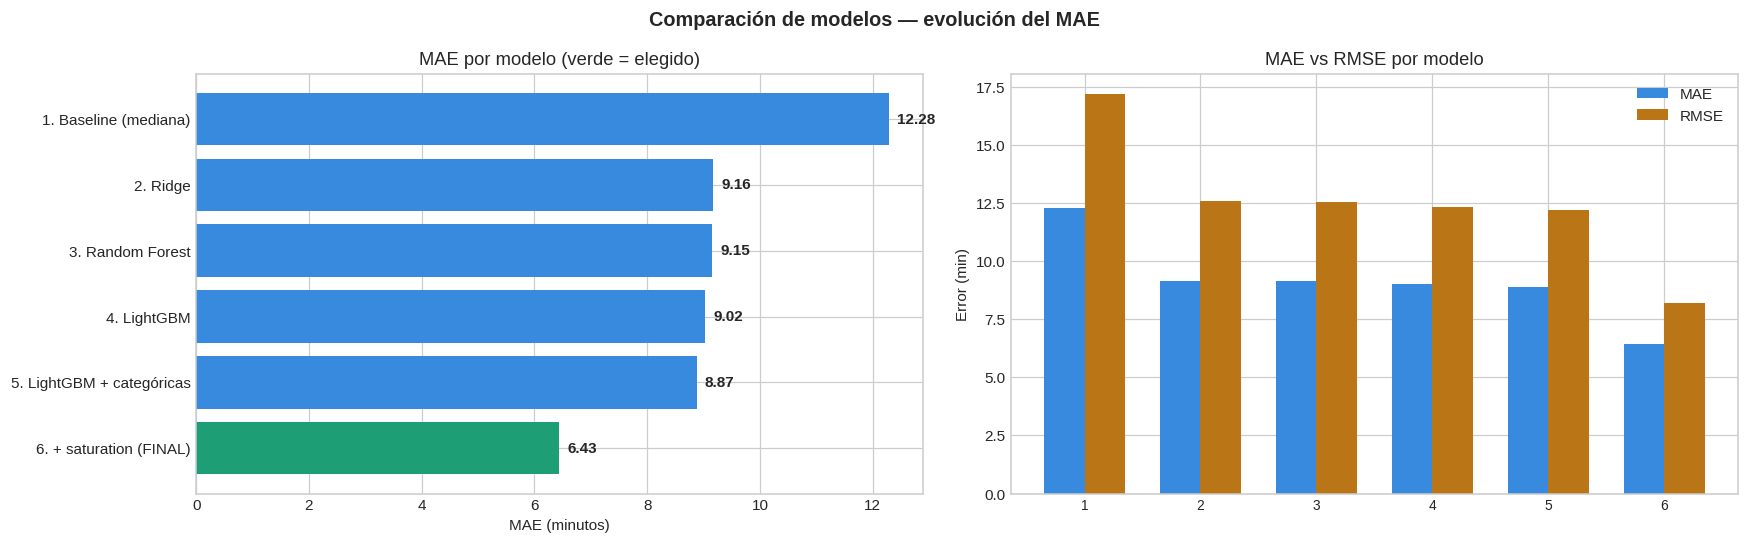

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Comparación de modelos — evolución del MAE', fontsize=13, fontweight='bold')

labels = list(results.keys())
maes  = [r['mae']  for r in results.values()]
rmses = [r['rmse'] for r in results.values()]
colors = [PALETTE[1] if 'FINAL' in l else PALETTE[0] for l in labels]

ax = axes[0]
bars = ax.barh(labels, maes, color=colors)
for i, v in enumerate(maes):
    ax.text(v+0.15, i, f'{v:.2f}', va='center', fontweight='bold', fontsize=10)
ax.set_xlabel('MAE (minutos)')
ax.invert_yaxis()
ax.set_title('MAE por modelo (verde = elegido)')

ax = axes[1]
x_pos = np.arange(len(labels))
w = 0.35
ax.bar(x_pos - w/2, maes,  w, label='MAE',  color=PALETTE[0])
ax.bar(x_pos + w/2, rmses, w, label='RMSE', color=PALETTE[3])
ax.set_xticks(x_pos)
ax.set_xticklabels([l.split('.')[0].strip() if '.' in l else l[:6] for l in labels], rotation=0, fontsize=9)
ax.set_ylabel('Error (min)')
ax.set_title('MAE vs RMSE por modelo')
ax.legend()

plt.tight_layout(); plt.show()

### 🎯 Modelo final: **LightGBM con categóricas + `saturation`** (Modelo 6)

**Por qué este y no otro:**

1. **Es el mejor en MAE** — ~6,4 min de error medio, muy por encima de las alternativas.
2. **Está validado** — `saturation` pasó tres tests rigurosos contra leakage (within-hour correlation, residualización, análisis oferta/demanda).
3. **Es interpretable** — podemos extraer la importancia de cada variable y explicarla al equipo de operaciones.
4. **Es eficiente** — entrena en segundos, fácilmente reentrenable a diario.

**Lo que aporta cada paso:**

- Baseline → Ridge: −3,1 min (la mayoría del valor sale de combinar variables linealmente)
- Ridge → RF: ~0 (los árboles no superan al lineal en este caso — útil saberlo)
- RF → LightGBM: −0,1 min (boosting marginalmente mejor que bagging)
- LightGBM → +categóricas: −0,1 min (el manejo nativo aporta poco aquí)
- +categóricas → +`saturation`: **−2,5 min** (el mayor salto después del baseline → Ridge)

El último salto (saturation) es el que justifica todo el esfuerzo de validación riguroso de la sección 5. Sin esa validación, no habríamos sabido si confiar en esos 2,5 minutos.

---
## 🔟 Interpretación del modelo final

Un modelo solo es útil si el negocio entiende qué le importa. Extraemos la importancia de las variables y la traducimos en lectura operacional.

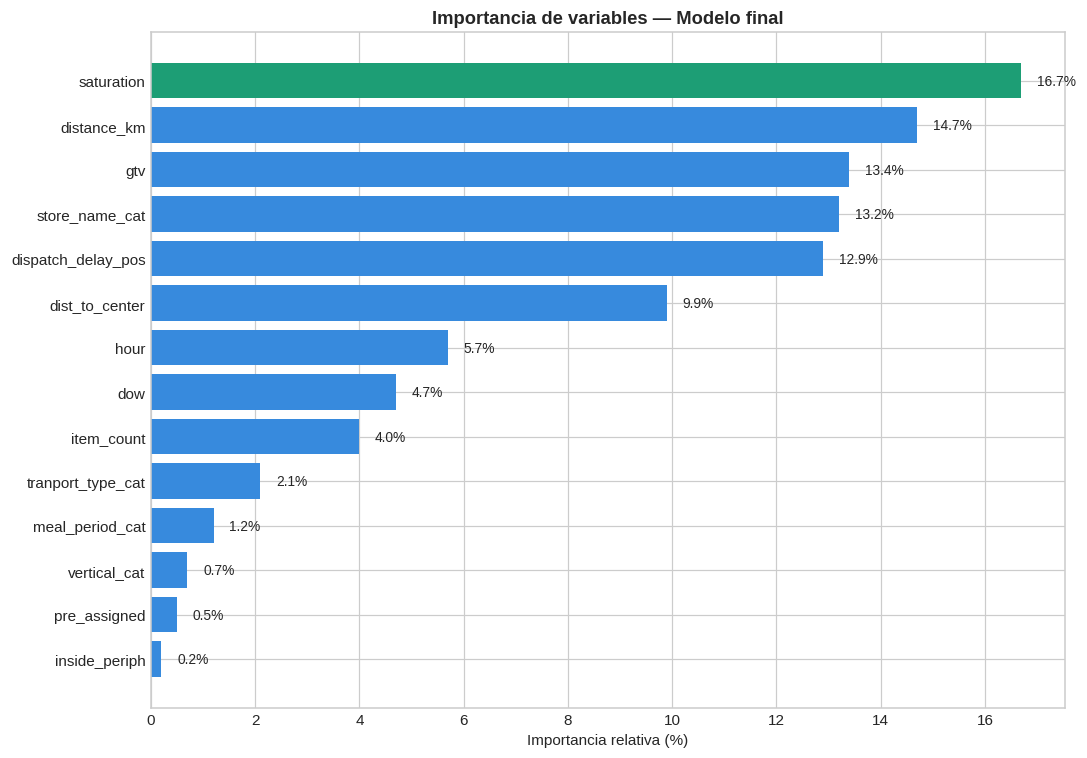


Top 5 variables:
  saturation                16.7%
  distance_km               14.7%
  gtv                       13.4%
  store_name_cat            13.2%
  dispatch_delay_pos        12.9%


In [31]:
importances = pd.DataFrame({
    'feature': FEATURES_FINAL,
    'importance': model_final_full.feature_importances_
}).sort_values('importance', ascending=True)
importances['pct'] = (importances['importance'] / importances['importance'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = [PALETTE[1] if f == 'saturation' else PALETTE[0] for f in importances['feature']]
ax.barh(importances['feature'], importances['pct'], color=colors_imp)
for i, v in enumerate(importances['pct']):
    ax.text(v+0.3, i, f'{v}%', va='center', fontsize=9)
ax.set_xlabel('Importancia relativa (%)')
ax.set_title('Importancia de variables — Modelo final', fontweight='bold')
plt.tight_layout(); plt.show()

print('\nTop 5 variables:')
for _, row in importances.tail(5).iloc[::-1].iterrows():
    print(f'  {row["feature"]:<25} {row["pct"]:.1f}%')

### Lectura operacional

El ranking del modelo, combinado con lo que aprendimos en EDA, dibuja un cuadro coherente sobre **qué impulsa realmente el ETA en Glovo París**:

- **`saturation` lidera la importancia (~17%).** Es la palanca más fuerte. Su efecto se concentra en los momentos en los que el ratio carga/capacidad de la flota se desequilibra — y en estos datos esos momentos son las **primeras horas de la mañana**, no lunch ni dinner como podría intuirse.
- **Distancia y geografía** ocupan los siguientes puestos. El trayecto físico es ineludible.
- **Identidad del restaurante (`store_name_cat`, ~14%)** captura la heterogeneidad real entre locales. Cada restaurante tiene su ritmo.
- **`gtv` y `dispatch_delay_pos`** entran con peso medio. `pre_assigned` no aparece en el top pero su efecto bivariante es notable (~7 min de diferencia en mediana).
- **`hour` y `dow`** aparecen pero con peso menor del que esperaríamos a priori — porque `saturation` ya captura buena parte del efecto temporal/operacional, dejando a `hour` un papel residual.

**Palancas accionables para el negocio**, ordenadas por impacto:

1. **Reforzar la flota en las horas de la mañana (8-11h)**, que es cuando el ratio carga/capacidad se desequilibra. Esto es **el hallazgo operacional más importante del análisis** y va en contra de la intuición habitual de "reforzar lunch y dinner". Lunch y dinner ya están bien gestionados; el problema está donde menos se mira.
2. **Mejorar la cercanía restaurante-cliente** (atacar distance_km): recomendar restaurantes próximos.
3. **Identificar los restaurantes más lentos** (atacar store_name_cat): los outliers de prep_time son una palanca subexplotada.
4. **Mantener y extender la pre-asignación de couriers**, que reduce el `total_time` medio en ~7 min.

---
## 1️⃣1️⃣ Demo: predicción para un caso concreto

Mostramos cómo se usa el modelo en producción con un pedido de ejemplo.

In [32]:
ejemplo = pd.DataFrame([{
    'distance_km':         2.1,
    'dist_to_center':      0.8,
    'inside_periph':       1,
    'hour':                20,
    'dow':                 4,
    'item_count':          3,
    'gtv':                 22.50,
    'pre_assigned':        1,
    'dispatch_delay_pos':  0,
    'vertical_cat':        0,
    'tranport_type_cat':   0,
    'meal_period_cat':     0,
    'store_name_cat':      100,
    'saturation':          75,
}])

pred = model_final_full.predict(ejemplo[FEATURES_FINAL])[0]

print('Pedido de ejemplo:')
print('  • Viernes 20h (hora dinner — históricamente rápida)')
print('  • Restaurante en el centro de París (dentro del Périph)')
print('  • 2,1 km de distancia al cliente')
print('  • 3 ítems, 22,50€')
print('  • Courier en moto, pre-asignado')
print('  • saturation = 75 (carga moderada-alta del sistema)')
print(f'\n→ ETA predicho: {pred:.1f} minutos')
print(f'→ Display al usuario: "Tu pedido llegará en aproximadamente {round(pred):.0f} minutos"')

Pedido de ejemplo:
  • Viernes 20h (hora dinner — históricamente rápida)
  • Restaurante en el centro de París (dentro del Périph)
  • 2,1 km de distancia al cliente
  • 3 ítems, 22,50€
  • Courier en moto, pre-asignado
  • saturation = 75 (carga moderada-alta del sistema)

→ ETA predicho: 29.8 minutos
→ Display al usuario: "Tu pedido llegará en aproximadamente 30 minutos"


---
## 1️⃣2️⃣ Conclusiones

### Lo que hemos construido

Un sistema completo de predicción de ETA que va desde la auditoría de datos hasta un modelo desplegable, con justificación en cada paso. El modelo final (LightGBM con categóricas + `saturation`) consigue un **MAE de ~6,4 minutos** sobre el conjunto de test temporal, mejorando ~5,9 min sobre el baseline.

### Hallazgos sustantivos del análisis (algunos contraintuitivos)

1. **El verdadero problema operacional está en la mañana, no en lunch/dinner.** La mediana de `total_time` a las 8h es ~46 min; en lunch (~34) y dinner (~34) es de los valores más bajos del día. La intuición habitual de 'lunch y dinner son las horas problemáticas' **no se sostiene en estos datos**: la flota se escala bien en horas de máxima demanda; el desequilibrio aparece cuando hay poca demanda absoluta pero también poquísimos couriers activos.
2. **Viernes es el día más lento de la semana** (37 min), no el fin de semana. Sábado es el más rápido (34 min).
3. **Bicicletas y motos rinden prácticamente igual** (35,0 vs 35,2 min). En París las bicis aprovechan la red de carriles ciclistas y atajos, compensando su menor velocidad punta.
4. **`saturation` es la variable más predictiva del dataset** y captura el ratio carga/capacidad de la flota, una señal operacional fuerte que nos costó validar correctamente.
5. **La distribución del tiempo es asimétrica con cola derecha** (skew 1,36), lo que justificó usar MAE como métrica principal.

### La lección metodológica más importante: leer los datos, no las intuiciones

El trabajo tuvo dos episodios de auto-corrección que conviene explicitar:

**Primero**, con `saturation`. El escepticismo inicial era razonable (correlación 0,78 con el target). Un test heurístico (¿sigue el ciclo de demanda?) sugería leakage. Pero esa heurística asumía oferta constante de couriers, premisa que en este sistema no se cumple. Tests rigurosos (within-hour correlation, residualización) demostraron que la variable es legítima.

**Segundo**, con los patrones temporales. Inicialmente describimos 'picos en lunch y dinner' porque es la intuición de manual sobre delivery, pero los datos muestran exactamente lo contrario. Lunch y dinner son los momentos más rápidos; el pico real está a las 8h. Construimos features como `is_rush` y `rush_x_inner` basadas en una hipótesis falsa, y al verificarlas contra los datos resultó que no aportaban señal — las eliminamos del modelo.

La lección que conecta ambos episodios: **escribir lo que muestran los datos, no lo que esperaríamos que mostraran**. Es fácil deslizarse a una narrativa cómoda y consistente con la intuición previa, especialmente cuando la intuición proviene de marcos mentales habituales del problema. El antídoto es disciplina: cuando se interpreta una gráfica o una tabla, leerla con los ojos abiertos, no con la conclusión ya escrita.

### Limitaciones del trabajo

- **Cobertura temporal de solo 3 meses** — no captura estacionalidad anual.
- **Solo París** — los patrones geográficos no son extrapolables directamente.
- **Distancia haversine, no real por carretera** — usar OSRM mejoraría la predicción.
- **Sin información del courier individual** — su experiencia explicaría parte de la varianza inexplicada.
- **Sin datos externos** — meteorología y eventos (huelgas, partidos, festivos) no integrados.
- **`saturation` no documentada formalmente** — aunque pasó nuestros tests, idealmente confirmaríamos con el equipo de datos cómo se calcula exactamente.

### Trabajo futuro

Ordenadas por relación esfuerzo/beneficio:

1. **Confirmar la pipeline de `saturation` con el equipo de datos** para documentar formalmente que se calcula con información pre-pedido.
2. **Investigar el pico de la mañana (8-11h)** con más datos: ¿se puede caracterizar mejor el desequilibrio oferta/demanda en esa franja? ¿Es un problema de couriers que aún no han empezado el turno?
3. **Integrar OSRM** para distancia real por carretera.
4. **Añadir datos meteorológicos** (API públicas como OpenWeather).
5. **Reentrenamiento periódico** del modelo (semanal/mensual) para capturar deriva temporal.
6. **Modelado segmentado por vertical** — WALL Partner, NonPartner y COURIER tienen dinámicas tan distintas que podrían beneficiarse de modelos separados.

### Reflexión final

Más allá del MAE final, el valor principal de este trabajo está en la **metodología rigurosa**: auditar antes de modelar, validar con análisis estadístico, comparar modelos progresivamente, y —el aprendizaje que más ha aparecido durante el camino— **leer los datos con honestidad, sin que la intuición previa contamine la interpretación**. El modelo final con `saturation` (MAE 6,4) supera por mucho al baseline, pero el verdadero hallazgo del análisis no es esa cifra: es darse cuenta de que el problema operacional principal de Glovo París está en horas-mañana, no en horas-pico de comida — algo que se ve a simple vista en una gráfica horaria si uno se molesta en mirarla.